# LSTM을 활용한 도곡역 3호선 시간대별 승차 수요 예측

서울교통공사 승하차 데이터를 사용하여 도곡역 3호선의 다음 시간대 총 승차 인원을 예측한다.

## 1. 문제 정의

- 서울 지하철 3호선 도곡역의 다음 시간대 승차 인원을 예측한다.
- 과거 시간대의 승차·하차 인원과 시간·요일·공휴일 정보를 입력으로 활용한다.
- 요일, 시간대, 공휴일 여부에 따라 승차 수요와 예측 오차가 어떻게 달라지는지 분석한다.

## 2. 데이터 설명

- 출처: 서울교통공사 1~8호선 역별 일별 시간대별 승객유형별 승하차인원
- 분석 기간: 2026년 1월 1일~6월 30일
- 분석 대상: 3호선 도곡역(역번호 334)
- 주요 변수: 수송일자, 승하차구분, 승객유형, 시간대별 승하차 인원

In [1]:
import random
import warnings

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

In [2]:
# 재현성을 위한 시드와 학습 장치 설정
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'학습 장치: {DEVICE}')

학습 장치: mps


In [3]:
DATA_PATH = './data/서울교통공사_1_8호선 역별 일별 시간대별 승객유형별 승하차인원_20260630.csv'

# 원본 CSV를 읽기 위해 CP949 인코딩을 사용한다.
df = pd.read_csv(DATA_PATH, encoding='cp949')


df.head()

,연번,수송일자,호선명,역번호,역명,승하차구분,승객유형,06시간대이전,06-07시간대,07-08시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시간대이후
0,1,2026-01-01,1호선,150,서울역,승차,일반,550,540,404,...,2596,2855,2941,2720,2655,1868,2188,1437,711,5
1,2,2026-01-01,1호선,150,서울역,승차,어린이,0,0,5,...,51,44,48,34,31,29,16,10,0,0
2,3,2026-01-01,1호선,150,서울역,승차,중고생,0,0,0,...,0,0,1,1,2,0,0,0,0,0
3,4,2026-01-01,1호선,150,서울역,승차,청소년,53,32,24,...,108,91,85,69,74,57,55,29,11,1
4,5,2026-01-01,1호선,150,서울역,승차,우대권,64,84,98,...,434,356,340,319,228,171,110,67,24,0


In [4]:
# 도곡역 3호선만 추출
dogok = df[
    (df['역명'] == '도곡')
    & (df['호선명'] == '3호선')
    & (df['역번호'] == 334)
].copy()

print(dogok.shape)
print('분석 기간:', dogok['수송일자'].min(), '~', dogok['수송일자'].max())
print('승하차 구분:', dogok['승하차구분'].unique())
print('승객 유형:', dogok['승객유형'].unique())

dogok.head()

(2256, 27)
분석 기간: 2026-01-01 ~ 2026-06-30
승하차 구분: <StringArray>
['승차', '하차']
Length: 2, dtype: str
승객 유형: <StringArray>
[     '일반',     '어린이',     '청소년',     '우대권',      '직원',   '영어 일반',     '중고생',
  '영어 어린이',  '중국어 일반',   '일어 일반', '중국어 어린이']
Length: 11, dtype: str


,연번,수송일자,호선명,역번호,역명,승하차구분,승객유형,06시간대이전,06-07시간대,07-08시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시간대이후
1590,1591,2026-01-01,3호선,334,도곡,승차,일반,12,19,28,...,92,105,106,95,70,70,94,63,9,0
1591,1592,2026-01-01,3호선,334,도곡,승차,어린이,0,0,0,...,3,1,2,1,0,0,2,1,0,0
1592,1593,2026-01-01,3호선,334,도곡,승차,청소년,2,1,5,...,7,5,6,11,1,0,6,2,2,0
1593,1594,2026-01-01,3호선,334,도곡,승차,우대권,7,22,9,...,30,25,30,19,17,23,11,6,0,0
1594,1595,2026-01-01,3호선,334,도곡,승차,직원,2,0,3,...,1,3,0,2,0,1,2,1,2,3


## 3. 전처리

승객유형별 행을 합산하되, 승차와 하차는 서로 다른 정보이므로 분리해 유지한다. `06시간대이전`과 `24시간대이후`는 정확한 1시간 구간이 아니므로 제외한다.

In [ ]:
# 규칙적인 1시간 단위 열만 선택 - 6시간대 이전과 24시간대 이후는 제외한다 
time_cols = [col for col in dogok.columns if '시간대' in col]
time_cols = [
    col for col in time_cols
    if col not in ['06시간대이전', '24시간대이후']
]

print(f'사용 시간대 수: {len(time_cols)}')
print(time_cols)

사용 시간대 수: 18
['06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대', '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대']


In [6]:
# 같은 날짜·승하차구분 내 모든 승객유형의 시간대별 인원을 합산
group_cols = ['수송일자', '승하차구분']

dogok_total = (
    dogok
    .groupby(group_cols, as_index=False)[time_cols]
    .sum()
)

print(f'승객유형 합산 후 데이터 크기: {dogok_total.shape[0]:,}행 × {dogok_total.shape[1]}열')
dogok_total.head()

승객유형 합산 후 데이터 크기: 362행 × 20열


,수송일자,승하차구분,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,14-15시간대,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대
0,2026-01-01,승차,42,45,70,72,102,93,101,109,145,133,139,144,128,88,94,115,73,13
1,2026-01-01,하차,70,66,95,136,92,107,97,110,100,81,125,149,103,91,92,89,75,47
2,2026-01-02,승차,176,437,486,296,264,233,288,265,293,306,447,591,602,276,192,182,160,38
3,2026-01-02,하차,172,407,657,416,253,227,249,260,256,256,253,366,510,340,232,162,175,105
4,2026-01-03,승차,59,124,169,159,213,290,251,291,285,282,296,277,196,121,99,149,108,30


In [7]:
# 날짜 feature 생성
dogok_total['수송일자'] = pd.to_datetime(dogok_total['수송일자'])
dogok_total = dogok_total.sort_values('수송일자').reset_index(drop=True)

dogok_total['dayofweek'] = dogok_total['수송일자'].dt.dayofweek
dogok_total['is_weekend'] = (dogok_total['dayofweek'] >= 5).astype(int)

kr_holidays = holidays.KR(years=[2026])
holiday_dates = pd.to_datetime(list(kr_holidays.keys()))
dogok_total['is_holiday'] = (
    dogok_total['수송일자'].dt.normalize().isin(holiday_dates).astype(int)
)

dogok_total.head()

,수송일자,승하차구분,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,dayofweek,is_weekend,is_holiday
0,2026-01-01,승차,42,45,70,72,102,93,101,109,...,144,128,88,94,115,73,13,3,0,1
1,2026-01-01,하차,70,66,95,136,92,107,97,110,...,149,103,91,92,89,75,47,3,0,1
2,2026-01-02,승차,176,437,486,296,264,233,288,265,...,591,602,276,192,182,160,38,4,0,0
3,2026-01-02,하차,172,407,657,416,253,227,249,260,...,366,510,340,232,162,175,105,4,0,0
4,2026-01-03,승차,59,124,169,159,213,290,251,291,...,277,196,121,99,149,108,30,5,1,0


In [8]:
# 전처리 결과 점검
print('전체 결측치 수:', dogok_total.isna().sum().sum())
print('날짜·승하차구분 중복 행 수:', dogok_total.duplicated(['수송일자', '승하차구분']).sum())
print('날짜별 행 개수 분포:')
print(dogok_total.groupby('수송일자').size().value_counts())

print('공휴일 예시:')
display(
    dogok_total.loc[dogok_total['is_holiday'] == 1,
                    ['수송일자', 'dayofweek', 'is_weekend', 'is_holiday']]
    .drop_duplicates()
    .head()
)

전체 결측치 수: 0
날짜·승하차구분 중복 행 수: 0
날짜별 행 개수 분포:
2    181
Name: count, dtype: int64
공휴일 예시:


,수송일자,dayofweek,is_weekend,is_holiday
0,2026-01-01,3,0,1
92,2026-02-16,0,0,1
94,2026-02-17,1,0,1
96,2026-02-18,2,0,1
118,2026-03-01,6,1,1


In [9]:
# 시간대의 순환성을 반영하는 feature 생성
time_feature_df = pd.DataFrame({'시간대': time_cols})
time_feature_df['hour'] = (
    time_feature_df['시간대'].str.extract(r'^(\d{2})')[0].astype(int)
)
time_feature_df['hour_sin'] = np.sin(2 * np.pi * time_feature_df['hour'] / 24)
time_feature_df['hour_cos'] = np.cos(2 * np.pi * time_feature_df['hour'] / 24)

time_feature_df

,시간대,hour,hour_sin,hour_cos
0,06-07시간대,6,1.000000e+00,6.123234e-17
1,07-08시간대,7,9.659258e-01,-2.588190e-01
2,08-09시간대,8,8.660254e-01,-5.000000e-01
3,09-10시간대,9,7.071068e-01,-7.071068e-01
4,10-11시간대,10,5.000000e-01,-8.660254e-01
5,11-12시간대,11,2.588190e-01,-9.659258e-01
6,12-13시간대,12,1.224647e-16,-1.000000e+00
7,13-14시간대,13,-2.588190e-01,-9.659258e-01
8,14-15시간대,14,-5.000000e-01,-8.660254e-01
9,15-16시간대,15,-7.071068e-01,-7.071068e-01


In [10]:
# 승차행과 하차행을 나누어 각각 boarding_df와 alighting_df 데이터프레임에 저장한다.
boarding_df = dogok_total[dogok_total['승하차구분'] == '승차'].copy()
alighting_df = dogok_total[dogok_total['승하차구분'] == '하차'].copy()

print('boarding_df.shape:', boarding_df.shape)
print('alighting_df.shape:', alighting_df.shape)

boarding_df.shape: (181, 23)
alighting_df.shape: (181, 23)


In [11]:
boarding_df.head()

,수송일자,승하차구분,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,dayofweek,is_weekend,is_holiday
0,2026-01-01,승차,42,45,70,72,102,93,101,109,...,144,128,88,94,115,73,13,3,0,1
2,2026-01-02,승차,176,437,486,296,264,233,288,265,...,591,602,276,192,182,160,38,4,0,0
4,2026-01-03,승차,59,124,169,159,213,290,251,291,...,277,196,121,99,149,108,30,5,1,0
6,2026-01-04,승차,41,54,99,158,173,161,219,196,...,192,158,79,116,128,86,23,6,1,0
9,2026-01-05,승차,243,521,657,358,300,273,286,281,...,684,851,448,310,217,175,28,0,0,0


18개 시간대 열을 `(날짜 수, 시간대 수, feature 수)` 배열로 변환한다.

In [12]:
boarding_values= boarding_df[time_cols].to_numpy(dtype=np.float32)

print(boarding_values.shape)
# boarding_values

alighting_values = alighting_df[time_cols].to_numpy(dtype=np.float32)
print(alighting_values.shape)
# alighting_values

board_alight_features = np.stack([boarding_values, alighting_values], axis=-1)
print(board_alight_features.shape)
board_alight_features # 한 시간대의 feature로 묶으려고 
# 181일 각 시간대(18개)마다 승차와 하차 데이터 feature을 묶는다 

(181, 18)
(181, 18)
(181, 18, 2)


array([[[  42.,   70.],
        [  45.,   66.],
        [  70.,   95.],
        ...,
        [ 115.,   89.],
        [  73.,   75.],
        [  13.,   47.]],

       [[ 176.,  172.],
        [ 437.,  407.],
        [ 486.,  657.],
        ...,
        [ 182.,  162.],
        [ 160.,  175.],
        [  38.,  105.]],

       [[  59.,  107.],
        [ 124.,  100.],
        [ 169.,  230.],
        ...,
        [ 149.,  129.],
        [ 108.,  143.],
        [  30.,   96.]],

       ...,

       [[  52.,   77.],
        [  67.,   79.],
        [ 120.,  186.],
        ...,
        [ 171.,  133.],
        [  91.,   96.],
        [  19.,   60.]],

       [[ 274.,  206.],
        [ 597.,  709.],
        [ 740., 1072.],
        ...,
        [ 250.,  230.],
        [ 147.,  177.],
        [  63.,   97.]],

       [[ 243.,  206.],
        [ 627.,  700.],
        [ 700., 1039.],
        ...,
        [ 251.,  249.],
        [ 174.,  205.],
        [  36.,  104.]]], shape=(181, 18, 2), dtype=float32

In [13]:
time_feature_df[['hour_sin','hour_cos']].shape

(18, 2)

In [14]:
dogok_total.head()

,수송일자,승하차구분,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,dayofweek,is_weekend,is_holiday
0,2026-01-01,승차,42,45,70,72,102,93,101,109,...,144,128,88,94,115,73,13,3,0,1
1,2026-01-01,하차,70,66,95,136,92,107,97,110,...,149,103,91,92,89,75,47,3,0,1
2,2026-01-02,승차,176,437,486,296,264,233,288,265,...,591,602,276,192,182,160,38,4,0,0
3,2026-01-02,하차,172,407,657,416,253,227,249,260,...,366,510,340,232,162,175,105,4,0,0
4,2026-01-03,승차,59,124,169,159,213,290,251,291,...,277,196,121,99,149,108,30,5,1,0


In [15]:
hour_values=time_feature_df[['hour_sin','hour_cos']].to_numpy(dtype=np.float32)
print(hour_values.shape)

hour_features = np.tile(hour_values,(len(boarding_df),1,1))

print(hour_features.shape)

(18, 2)
(181, 18, 2)


In [16]:
date_values = boarding_df[['dayofweek','is_weekend','is_holiday']].to_numpy(dtype=np.float32)
print(date_values.shape)
# date_values
# 가운데에 시간대 축을 새로 추가
date_values_3d = date_values[:, np.newaxis, :]
print(date_values_3d.shape)  # (181, 1, 3)

# 시간대 축(axis=1)을 18번 반복
date_features = np.repeat(
    date_values_3d,
    repeats=len(time_cols),
    axis=1
)

print(date_features.shape)  # (181, 18, 3)

(181, 3)
(181, 1, 3)
(181, 18, 3)


In [17]:
print(board_alight_features.shape)
print(hour_features.shape)
print(date_features.shape)

(181, 18, 2)
(181, 18, 2)
(181, 18, 3)


In [18]:
all_features= np.concatenate([board_alight_features, hour_features, date_features], axis=-1)
print(all_features.shape)

(181, 18, 7)


In [19]:
boarding_df = boarding_df.sort_values('수송일자').reset_index(drop=True)
alighting_df = alighting_df.sort_values('수송일자').reset_index(drop=True)

assert boarding_df['수송일자'].equals(alighting_df['수송일자'])
print('승차·하차 날짜 순서가 동일합니다.')

승차·하차 날짜 순서가 동일합니다.


## 4. LSTM 입력 구조와 데이터 준비

날짜 순서를 유지한 채 Train, Validation, Test로 나눈 뒤, Train 데이터의 승차·하차 인원으로만 fit를 수행한다.

In [20]:
# 날짜 수 기준으로 순서대로 분할
n_days = len(all_features)

train_end = int(n_days * 0.70)
val_end = int(n_days * 0.85)

X_train_days = all_features[:train_end]
X_val_days = all_features[train_end:val_end]
X_test_days = all_features[val_end:]

train_dates = boarding_df['수송일자'].iloc[:train_end]
val_dates = boarding_df['수송일자'].iloc[train_end:val_end]
test_dates = boarding_df['수송일자'].iloc[val_end:]

print('Train:', X_train_days.shape)
print('Validation:', X_val_days.shape)
print('Test:', X_test_days.shape)

print()
print('Train 기간:', train_dates.iloc[0], '~', train_dates.iloc[-1])
print('Validation 기간:', val_dates.iloc[0], '~', val_dates.iloc[-1])
print('Test 기간:', test_dates.iloc[0], '~', test_dates.iloc[-1])

Train: (126, 18, 7)
Validation: (27, 18, 7)
Test: (28, 18, 7)

Train 기간: 2026-01-01 00:00:00 ~ 2026-05-06 00:00:00
Validation 기간: 2026-05-07 00:00:00 ~ 2026-06-02 00:00:00
Test 기간: 2026-06-03 00:00:00 ~ 2026-06-30 00:00:00


### 4-1. 날짜 기준 분할과 표준화

미래 정보가 학습에 섞이지 않도록 날짜 순서대로 70% / 15% / 15%로 분할한다.

In [21]:

boarding_scaler = StandardScaler()
alighting_scaler = StandardScaler()

boarding_scaler.fit(
  X_train_days[:,:,0].reshape(-1, 1)
)

alighting_scaler.fit(
  X_train_days[:,:,1].reshape(-1, 1)
)

StandardScaler()

In [22]:
def scale_flow_features(day_features): # day_features
    """
    day_features.shape: (날짜 수, 시간대 수, 7개 feature)

    feature 0: 승차 인원
    feature 1: 하차 인원
    feature 2~6: 시간·날짜 feature이므로 그대로 유지
    """
    scaled_features = day_features.copy()

    # 승차 인원 표준화
    boarding_values = scaled_features[:, :, 0].reshape(-1, 1)
    scaled_features[:, :, 0] = boarding_scaler.transform(
        boarding_values
    ).reshape(scaled_features.shape[0], scaled_features.shape[1])

    # 하차 인원 표준화
    alighting_values = scaled_features[:, :, 1].reshape(-1, 1)
    scaled_features[:, :, 1] = alighting_scaler.transform(
        alighting_values
    ).reshape(scaled_features.shape[0], scaled_features.shape[1])

    return scaled_features


# Train에서 학습한 scaler를 모든 분할 데이터에 적용
X_train_scaled = scale_flow_features(X_train_days)
X_val_scaled = scale_flow_features(X_val_days)
X_test_scaled = scale_flow_features(X_test_days)

print('Train:', X_train_scaled.shape)
print('Validation:', X_val_scaled.shape)
print('Test:', X_test_scaled.shape)

Train: (126, 18, 7)
Validation: (27, 18, 7)
Test: (28, 18, 7)


### 4-2. 시퀀스 생성과 DataLoader

같은 날짜 안에서 직전 6개 시간대의 feature를 입력으로 사용하고, 다음 시간대의 승차 인원을 예측한다.

In [23]:
# 직전 6개 시간대를 보고 다음 시간대의 승차 인원을 예측
SEQUENCE_LENGTH = 6


def make_sequences(day_features, sequence_length):
    """
    day_features shape: (날짜 수, 시간대 수, feature 수)

    X: 직전 sequence_length개 시간대의 모든 feature
    y: 다음 시간대의 승차 인원(feature 0)
    """
    X_seq = []
    y_seq = []
    target_day_idx = []
    target_time_idx = []

    n_days, n_times, _ = day_features.shape

    for day_idx in range(n_days):
        # target_idx=6이면:
        # X = 06~12시의 6개 시간대, y = 12~13시 승차 인원
        for target_idx in range(sequence_length, n_times):
            X_seq.append(
                day_features[
                    day_idx,
                    target_idx - sequence_length:target_idx,
                    :
                ]
            )

            # feature 0 = 표준화된 승차 인원
            y_seq.append(day_features[day_idx, target_idx, 0])

            # 나중에 날짜·시간대별 평가에 활용할 정보
            target_day_idx.append(day_idx)
            target_time_idx.append(target_idx)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32).reshape(-1, 1),
        np.asarray(target_day_idx, dtype=np.int32),
        np.asarray(target_time_idx, dtype=np.int32)
    )

In [24]:
X_train, y_train, train_day_idx, train_time_idx = make_sequences(
    X_train_scaled,
    SEQUENCE_LENGTH
)

X_val, y_val, val_day_idx, val_time_idx = make_sequences(
    X_val_scaled,
    SEQUENCE_LENGTH
)

X_test, y_test, test_day_idx, test_time_idx = make_sequences(
    X_test_scaled,
    SEQUENCE_LENGTH
)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_val:', X_val.shape, '| y_val:', y_val.shape)
print('X_test:', X_test.shape, '| y_test:', y_test.shape)

X_train: (1512, 6, 7) | y_train: (1512, 1)
X_val: (324, 6, 7) | y_val: (324, 1)
X_test: (336, 6, 7) | y_test: (336, 1)


In [25]:
# NumPy 시퀀스 배열을 PyTorch Dataset 형태로 변환
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [26]:
BATCH_SIZE = 32

train_loader = DataLoader(
    SequenceDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    SequenceDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    SequenceDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [27]:
sample_X, sample_y = next(iter(train_loader))

print('입력 X shape:', sample_X.shape)
print('정답 y shape:', sample_y.shape)

입력 X shape: torch.Size([32, 6, 7])
정답 y shape: torch.Size([32, 1])


## 5. 모델 구조

입력 feature 7개를 사용하고, hidden size 32의 단일 LSTM 층으로 다음 시간대 승차 인원을 회귀 예측한다.

In [28]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        lstm_out, _ = self.lstm(x)

        # 마지막 시간대의 LSTM 출력만 사용
        last_hidden = lstm_out[:, -1, :]

        # 다음 시간대 승차 인원 1개 예측
        prediction = self.fc(last_hidden)

        return prediction

In [29]:
INPUT_SIZE = X_train.shape[2]  # 7
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.0

model = LSTMRegressor(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

print(model)

LSTMRegressor(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [30]:
model.eval()

with torch.no_grad():
    sample_X = sample_X.to(DEVICE)
    sample_pred = model(sample_X)

print('입력 shape:', sample_X.shape)
print('예측 shape:', sample_pred.shape)

입력 shape: torch.Size([32, 6, 7])
예측 shape: torch.Size([32, 1])


## 6. 학습 방법

MSE Loss와 AdamW optimizer를 사용하며, validation loss 기준 early stopping으로 과적합을 줄인다.

In [31]:
# 학습 설정
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 8

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None
patience_count = 0

In [32]:
import copy

In [33]:
for epoch in range(EPOCHS):
    # --------------------
    # Train
    # --------------------
    model.train()
    train_loss_sum = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        loss.backward()

        # 기울기가 너무 커지는 것을 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss_sum += loss.item() * X_batch.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --------------------
    # Validation
    # --------------------
    model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            val_loss_sum += loss.item() * X_batch.size(0)

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_losses.append(val_loss)

    print(
        f'Epoch {epoch + 1:02d}/{EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f}'
    )

    # Validation loss가 가장 낮은 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

        if patience_count >= PATIENCE:
            print(f'\nEarly stopping: epoch {epoch + 1}에서 학습을 종료합니다.')
            break

# 가장 좋았던 validation 성능의 모델로 복원
model.load_state_dict(best_model_state)

print(f'\nBest Validation Loss: {best_val_loss:.4f}')

Epoch 01/50 | Train Loss: 0.8620 | Val Loss: 0.7055
Epoch 02/50 | Train Loss: 0.4922 | Val Loss: 0.3163
Epoch 03/50 | Train Loss: 0.2581 | Val Loss: 0.1846
Epoch 04/50 | Train Loss: 0.1787 | Val Loss: 0.1615
Epoch 05/50 | Train Loss: 0.1450 | Val Loss: 0.1241
Epoch 06/50 | Train Loss: 0.1225 | Val Loss: 0.1391
Epoch 07/50 | Train Loss: 0.1121 | Val Loss: 0.0884
Epoch 08/50 | Train Loss: 0.0963 | Val Loss: 0.0800
Epoch 09/50 | Train Loss: 0.0885 | Val Loss: 0.1045
Epoch 10/50 | Train Loss: 0.0814 | Val Loss: 0.0739
Epoch 11/50 | Train Loss: 0.0659 | Val Loss: 0.0678
Epoch 12/50 | Train Loss: 0.0599 | Val Loss: 0.0774
Epoch 13/50 | Train Loss: 0.0543 | Val Loss: 0.0669
Epoch 14/50 | Train Loss: 0.0498 | Val Loss: 0.0612
Epoch 15/50 | Train Loss: 0.0461 | Val Loss: 0.0494
Epoch 16/50 | Train Loss: 0.0453 | Val Loss: 0.0463
Epoch 17/50 | Train Loss: 0.0436 | Val Loss: 0.0461
Epoch 18/50 | Train Loss: 0.0395 | Val Loss: 0.0456
Epoch 19/50 | Train Loss: 0.0400 | Val Loss: 0.0412
Epoch 20/50 

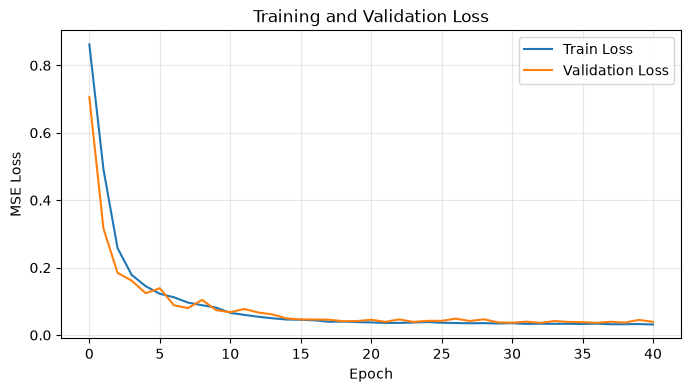

In [34]:
plt.figure(figsize=(8, 4))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6-1. 시퀀스 길이 비교 실험

오전 출근 시간대(08-09시)를 예측 대상에 포함하기 위해 2시간 시퀀스를 추가로 학습한다. 최종 시퀀스 길이는 Test 데이터가 아닌 Validation RMSE와 MAE를 기준으로 선택한다.

In [35]:
def evaluate_validation_metrics(model, data_loader):
    """Validation 예측값을 실제 승차 인원 단위로 복원해 RMSE와 MAE를 계산한다."""
    model.eval()
    pred_scaled_list = []
    y_scaled_list = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(DEVICE)
            pred_scaled_list.append(model(X_batch).cpu().numpy())
            y_scaled_list.append(y_batch.numpy())

    pred_scaled = np.vstack(pred_scaled_list)
    y_scaled = np.vstack(y_scaled_list)
    pred = boarding_scaler.inverse_transform(pred_scaled)
    y_true = boarding_scaler.inverse_transform(y_scaled)

    return {
        'RMSE': root_mean_squared_error(y_true, pred),
        'MAE': mean_absolute_error(y_true, pred)
    }

seq6_val_metrics = evaluate_validation_metrics(model, val_loader)
print(f"6시간 시퀀스 Validation RMSE: {seq6_val_metrics['RMSE']:.2f}명")
print(f"6시간 시퀀스 Validation MAE: {seq6_val_metrics['MAE']:.2f}명")


6시간 시퀀스 Validation RMSE: 38.55명
6시간 시퀀스 Validation MAE: 27.55명


In [36]:
# 2시간 시퀀스 데이터 생성: 08-09시간대부터 예측 가능
SEQUENCE_LENGTH_2 = 2

X_train_seq2, y_train_seq2, _, _ = make_sequences(X_train_scaled, SEQUENCE_LENGTH_2)
X_val_seq2, y_val_seq2, _, _ = make_sequences(X_val_scaled, SEQUENCE_LENGTH_2)

train_loader_seq2 = DataLoader(SequenceDataset(X_train_seq2, y_train_seq2), batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq2 = DataLoader(SequenceDataset(X_val_seq2, y_val_seq2), batch_size=BATCH_SIZE, shuffle=False)

print('X_train_seq2:', X_train_seq2.shape)
print('X_val_seq2:', X_val_seq2.shape)


X_train_seq2: (2016, 2, 7)
X_val_seq2: (432, 2, 7)


In [37]:
# 기존 6시간 모델은 유지하고, 2시간 모델을 별도로 학습한다.
torch.manual_seed(SEED)

model_seq2 = LSTMRegressor(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
optimizer_seq2 = torch.optim.AdamW(model_seq2.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

best_val_loss_seq2 = float('inf')
best_model_state_seq2 = None
patience_count_seq2 = 0

for epoch in range(EPOCHS):
    model_seq2.train()
    for X_batch, y_batch in train_loader_seq2:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_seq2.zero_grad()
        loss = criterion(model_seq2(X_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_seq2.parameters(), max_norm=1.0)
        optimizer_seq2.step()

    model_seq2.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_seq2:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            val_loss_sum += criterion(model_seq2(X_batch), y_batch).item() * X_batch.size(0)

    val_loss = val_loss_sum / len(val_loader_seq2.dataset)
    if val_loss < best_val_loss_seq2:
        best_val_loss_seq2 = val_loss
        best_model_state_seq2 = copy.deepcopy(model_seq2.state_dict())
        patience_count_seq2 = 0
    else:
        patience_count_seq2 += 1
        if patience_count_seq2 >= PATIENCE:
            print(f'Early stopping: epoch {epoch + 1}')
            break

model_seq2.load_state_dict(best_model_state_seq2)
print(f'2시간 시퀀스 Best Validation Loss: {best_val_loss_seq2:.4f}')


2시간 시퀀스 Best Validation Loss: 0.0476


In [38]:
seq2_val_metrics = evaluate_validation_metrics(model_seq2, val_loader_seq2)

sequence_length_comparison = pd.DataFrame(
    [seq6_val_metrics, seq2_val_metrics],
    index=['6시간 시퀀스', '2시간 시퀀스']
)

sequence_length_comparison


,RMSE,MAE
6시간 시퀀스,38.547951,27.548611
2시간 시퀀스,44.193092,30.868513


시퀀스 길이에 따른 validation 성능을 추가 비교 진행하였다. 
직전 6시간을 사용하는 모델의 RMSE와 MAE는 각각 38.55명, 27.55명으로, 직전 2시간을 사용하는 모델의 44.19명, 30.87명보다 낮았다. 따라서 도곡역의 승차 수요 예측에는 짧은 직전 흐름보다 최근 6시간의 이용 패턴이 더 유용하다고 판단하여, 최종 모델의 sequence length를 6으로 선택하였다.

다만 2시간 모델은 오전 08-09시간대부터 예측할 수 있는 반면, 6시간 모델은 12-13시간대부터 예측한다

## 7. 결과 및 평가

Test 데이터에서 RMSE와 MAE를 계산하고, 직전 시간대 승차 인원을 그대로 사용하는 Naive Baseline과 비교한다.

In [39]:
# Test 데이터 예측
model.eval()

pred_scaled_list = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)

        pred_scaled = model(X_batch)
        pred_scaled_list.append(pred_scaled.cpu().numpy())

pred_scaled = np.vstack(pred_scaled_list)

# y_test와 예측값을 실제 승차 인원 단위로 복원
y_true = boarding_scaler.inverse_transform(y_test)
y_pred = boarding_scaler.inverse_transform(pred_scaled)

print('실제값 shape:', y_true.shape)
print('예측값 shape:', y_pred.shape)

실제값 shape: (336, 1)
예측값 shape: (336, 1)


In [40]:
# Naive baseline:
# 다음 시간대 승차 인원은 직전 시간대 승차 인원과 같다고 가정
naive_pred_scaled = X_test[:, -1, 0].reshape(-1, 1)
naive_pred = boarding_scaler.inverse_transform(naive_pred_scaled)

In [41]:
def regression_metrics(y_true, y_pred):
    return {
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred)
    }


lstm_metrics = regression_metrics(y_true, y_pred)
naive_metrics = regression_metrics(y_true, naive_pred)

comparison = pd.DataFrame(
    [lstm_metrics, naive_metrics],
    index=['LSTM', 'Naive Baseline']
)

comparison

,RMSE,MAE
LSTM,37.936031,26.882540
Naive Baseline,140.116562,92.901787


In [42]:
results_df = pd.DataFrame({
    '수송일자': test_dates.iloc[test_day_idx].to_numpy(),
    '예측시간대': np.array(time_cols)[test_time_idx],
    '실제_승차인원': y_true.ravel(),
    'LSTM_예측': y_pred.ravel(),
    'Naive_예측': naive_pred.ravel()
})

results_df['LSTM_절대오차'] = (
    results_df['실제_승차인원'] - results_df['LSTM_예측']
).abs()

results_df.head()

,수송일자,예측시간대,실제_승차인원,LSTM_예측,Naive_예측,LSTM_절대오차
0,2026-06-03,12-13시간대,274.0,258.356750,219.0,15.643250
1,2026-06-03,13-14시간대,242.0,280.058044,274.0,38.058044
2,2026-06-03,14-15시간대,276.0,272.965790,242.0,3.034210
3,2026-06-03,15-16시간대,250.0,270.530518,276.0,20.530518
4,2026-06-03,16-17시간대,251.0,259.408813,250.0,8.408813


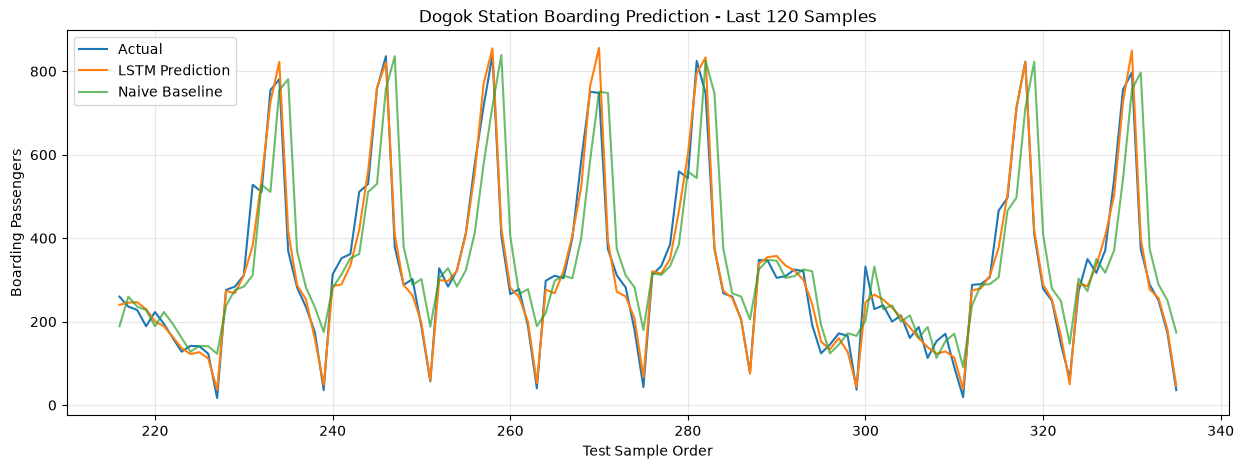

In [43]:
N_VIEW = 120

plt.figure(figsize=(15, 5))

plt.plot(
    results_df.index[-N_VIEW:],
    results_df['실제_승차인원'].iloc[-N_VIEW:],
    label='Actual'
)

plt.plot(
    results_df.index[-N_VIEW:],
    results_df['LSTM_예측'].iloc[-N_VIEW:],
    label='LSTM Prediction'
)

plt.plot(
    results_df.index[-N_VIEW:],
    results_df['Naive_예측'].iloc[-N_VIEW:],
    label='Naive Baseline',
    alpha=0.7
)

plt.title(f'Dogok Station Boarding Prediction - Last {N_VIEW} Samples')
plt.xlabel('Test Sample Order')
plt.ylabel('Boarding Passengers')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. 결과 분석



In [44]:
# 테스트 기간의 날짜 feature를 결과표에 추가
test_day_info = (
    boarding_df[
        ['수송일자', 'dayofweek', 'is_weekend', 'is_holiday']
    ]
    .iloc[val_end:]
    .reset_index(drop=True)
)

results_df = results_df.merge(
    test_day_info,
    on='수송일자',
    how='left'
)

results_df.head()

,수송일자,예측시간대,실제_승차인원,LSTM_예측,Naive_예측,LSTM_절대오차,dayofweek,is_weekend,is_holiday
0,2026-06-03,12-13시간대,274.0,258.356750,219.0,15.643250,2,0,1
1,2026-06-03,13-14시간대,242.0,280.058044,274.0,38.058044,2,0,1
2,2026-06-03,14-15시간대,276.0,272.965790,242.0,3.034210,2,0,1
3,2026-06-03,15-16시간대,250.0,270.530518,276.0,20.530518,2,0,1
4,2026-06-03,16-17시간대,251.0,259.408813,250.0,8.408813,2,0,1


In [45]:
time_error = (
    results_df
    .groupby('예측시간대')['LSTM_절대오차']
    .agg(['mean', 'median', 'count'])
    .reindex(time_cols[SEQUENCE_LENGTH:])
)

time_error

,mean,median,count
예측시간대,,,
12-13시간대,30.120630,19.105850,28
13-14시간대,29.786940,27.191620,28
14-15시간대,26.500311,25.069870,28
15-16시간대,56.014549,38.058578,28
16-17시간대,38.114571,35.821564,28
17-18시간대,25.979391,26.694328,28
18-19시간대,29.492538,25.344055,28
19-20시간대,22.854355,20.715729,28
20-21시간대,16.260447,11.716736,28


In [46]:
plt.rcParams['font.family'] = 'AppleGothic'

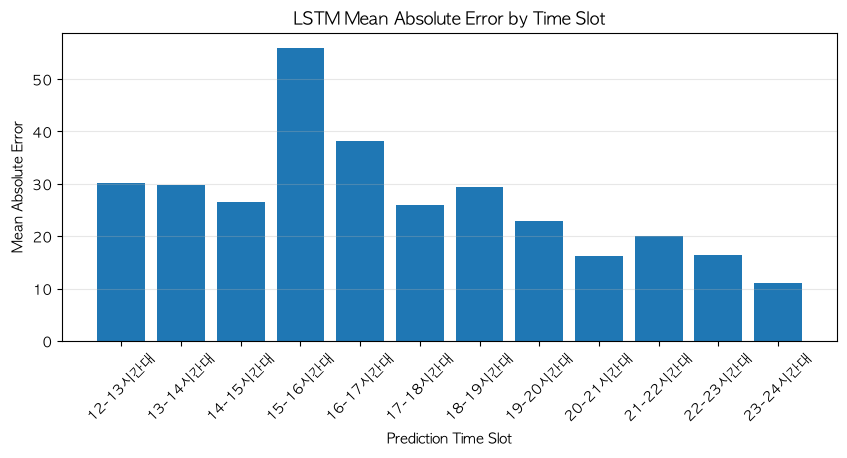

In [47]:
plt.figure(figsize=(10, 4))

plt.bar(time_error.index, time_error['mean'])
plt.xticks(rotation=45)
plt.xlabel('Prediction Time Slot')
plt.ylabel('Mean Absolute Error')
plt.title('LSTM Mean Absolute Error by Time Slot')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 8-2. 평일과 주말의 오차 비교

In [48]:
weekend_error = (
    results_df
    .groupby('is_weekend')['LSTM_절대오차']
    .agg(['mean', 'median', 'count'])
)

weekend_error.index = ['평일', '주말']
weekend_error

,mean,median,count
평일,27.522358,19.759979,240
주말,25.282988,19.674370,96


### 8-3. 공휴일 오차 확인

공휴일 표본 수가 적다면 결과를 일반화하기보다 참고용으로 해석한다.

In [49]:
holiday_error = (
    results_df
    .groupby('is_holiday')['LSTM_절대오차']
    .agg(['mean', 'median', 'count'])
)

holiday_error.index = ['비공휴일', '공휴일']
holiday_error

,mean,median,count
비공휴일,26.859842,19.611664,312
공휴일,27.177591,23.988701,24


In [50]:
time_error = (
    results_df
    .groupby('예측시간대')['LSTM_절대오차']
    .agg(['mean', 'median', 'count'])
    .reindex(time_cols[SEQUENCE_LENGTH:])
)

time_error

,mean,median,count
예측시간대,,,
12-13시간대,30.120630,19.105850,28
13-14시간대,29.786940,27.191620,28
14-15시간대,26.500311,25.069870,28
15-16시간대,56.014549,38.058578,28
16-17시간대,38.114571,35.821564,28
17-18시간대,25.979391,26.694328,28
18-19시간대,29.492538,25.344055,28
19-20시간대,22.854355,20.715729,28
20-21시간대,16.260447,11.716736,28


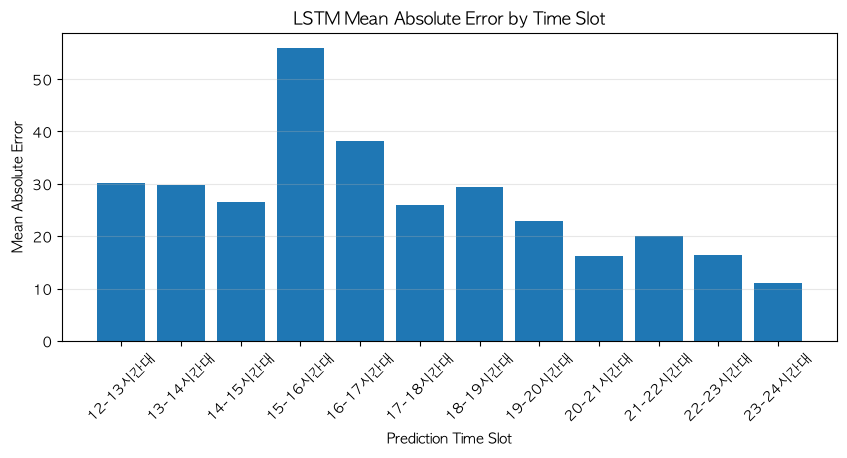

In [51]:
plt.figure(figsize=(10, 4))

plt.bar(time_error.index, time_error['mean'])
plt.xticks(rotation=45)
plt.xlabel('Prediction Time Slot')
plt.ylabel('Mean Absolute Error')
plt.title('LSTM Mean Absolute Error by Time Slot')
plt.grid(axis='y', alpha=0.3)
plt.show()